In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
def mostrar(img, titulo="", cmap="gray", figsize=(12,4)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(titulo)
    plt.axis("off")
    plt.show()

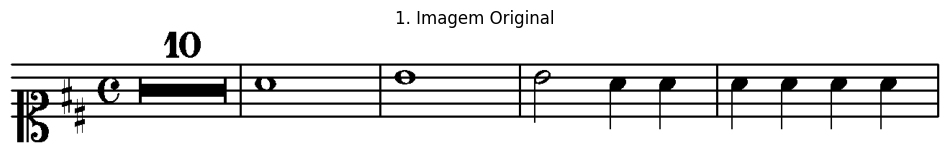

In [ ]:
caminho_imagem = "partitura.png"
pasta_destino = "output_simbolos"

if not os.path.exists(pasta_destino):
    os.makedirs(pasta_destino)

    # =========================================================
    # 1. CARREGAR IMAGEM
    # =========================================================
img = cv2.imread(caminho_imagem, 0)

if img is None:
    print("Erro ao carregar imagem")

mostrar(img, "1. Imagem Original")


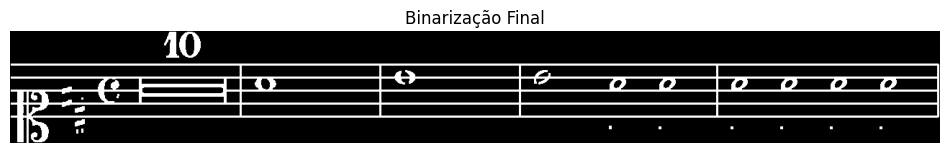

: 

In [ ]:
# contraste
clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8,8)
)

img2 = clahe.apply(img)

# blur
blur = cv2.GaussianBlur(img2, (3,3), 0)

# threshold adaptativo
binary = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    19,
    10
)

# limpeza
kernel = np.ones((3,3), np.uint8)

binary = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

mostrar(binary, "Binarização Final")

In [ ]:
# =========================================================
# DETECTAR LINHAS HORIZONTAIS
# =========================================================

altura, largura = binary.shape

kernel_horizontal = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (largura // 12, 1)
)

linhas = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel_horizontal
)

# =========================================================
# CONECTAR LINHAS FINAS/QUEBRADAS
# =========================================================

#kernel_conectar = cv2.getStructuringElement(
#    cv2.MORPH_RECT,
#    (25, 1)
#)

#linhas_detectadas = cv2.dilate(
#    linhas,
#    kernel_conectar,
#    iterations=1
#)

mostrar(linhas, "Linhas Detectadas")

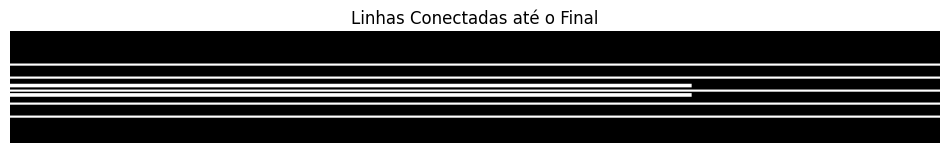

In [ ]:
# 1. Pegar as dimensões da imagem
altura, largura = linhas.shape

# 2. Criar um kernel com a largura TOTAL da imagem
kernel_total = cv2.getStructuringElement(cv2.MORPH_RECT, (largura, 1))

# 3. Aplicar a dilatação para esticar todas as linhas horizontalmente
linhas_completas = cv2.dilate(linhas, kernel_total, iterations=1)

mostrar(linhas_completas, "Linhas Conectadas até o Final")

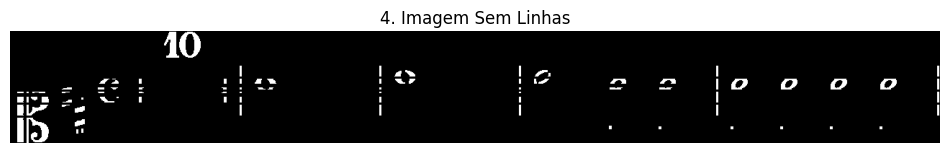

In [ ]:
 # =========================================================
    # 4. REMOVER LINHAS
    # =========================================================
linhas_completas = cv2.erode(
    linhas_completas,
    cv2.getStructuringElement(cv2.MORPH_RECT, (3,1)),
    iterations=1
)

sem_linhas = cv2.subtract(binary, linhas_completas)

mostrar(sem_linhas, "4. Imagem Sem Linhas")


In [ ]:

# =========================================================
# RECONSTRUIR SÍMBOLOS HORIZONTAIS
# =========================================================

#kernel_reconstrucao = cv2.getStructuringElement(
#    cv2.MORPH_RECT,
#    (15,1)
#)

#sem_linhas = cv2.dilate(
#    sem_linhas,
#    kernel_reconstrucao,
#    iterations=1
#)

# afina novamente
#sem_linhas = cv2.erode(
#    sem_linhas,
#    kernel_reconstrucao,
#    iterations=1
#)

#mostrar(sem_linhas, "4. Imagem Sem Linhas")

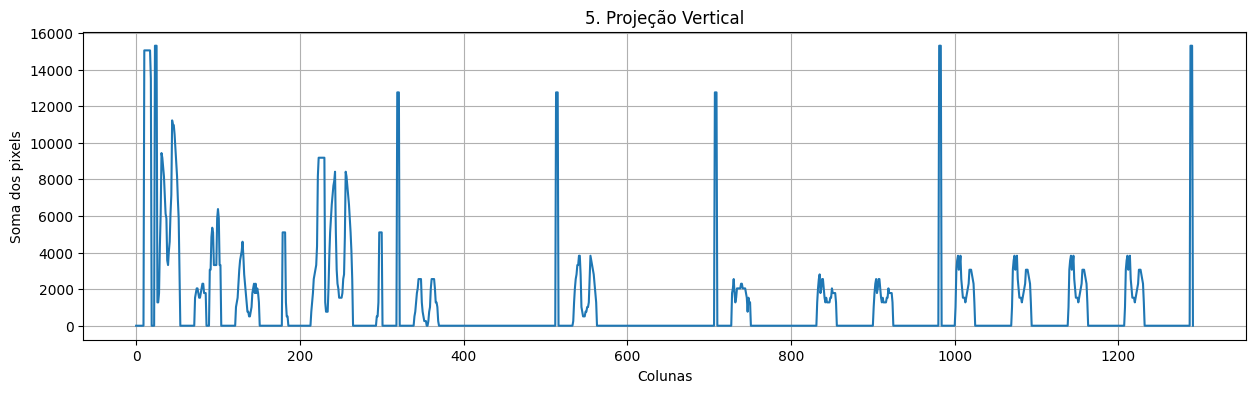

In [ ]:
# =========================================================
# 5. PROJEÇÃO VERTICAL
# =========================================================
projecao = np.sum(sem_linhas, axis=0)

plt.figure(figsize=(15,4))
plt.plot(projecao)
plt.title("5. Projeção Vertical")
plt.xlabel("Colunas")
plt.ylabel("Soma dos pixels")
plt.grid()
plt.show()

20 símbolos encontrados


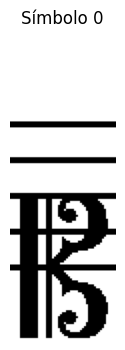

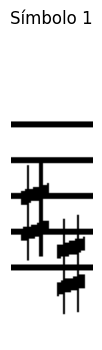

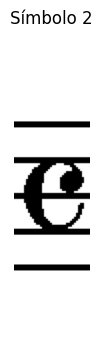

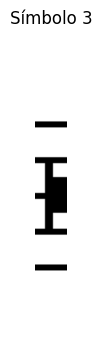

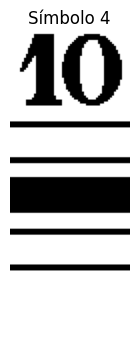

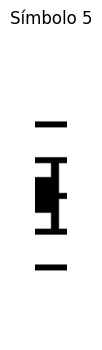

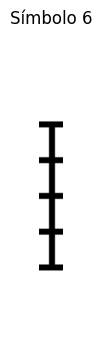

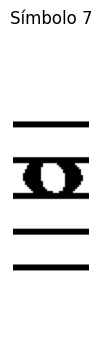

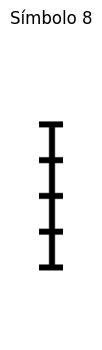

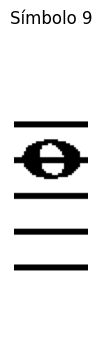

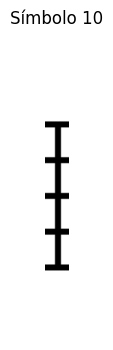

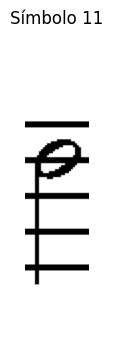

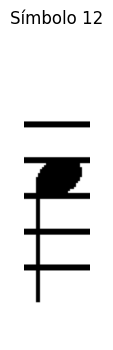

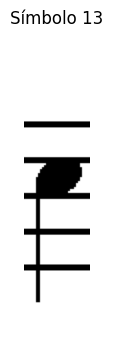

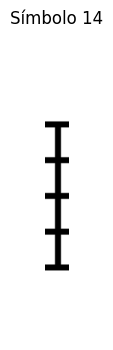

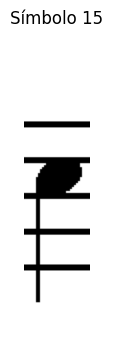

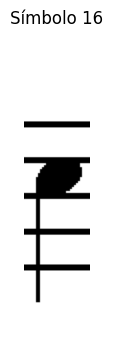

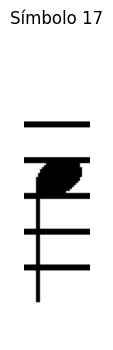

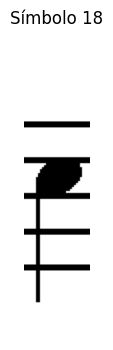

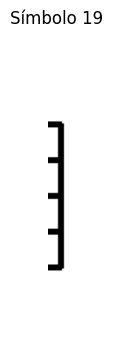

In [ ]:
# =========================================================
# 6. EXTRAÇÃO DOS SÍMBOLOS
# =========================================================
simbolos = []

em_simbolo = False
inicio = 0

espaco_max_vazio = 7
contador_vazio = 0

for x, valor in enumerate(projecao):

        if valor > 500:

            if not em_simbolo:
                inicio = x
                em_simbolo = True

            contador_vazio = 0

        elif valor <= 500 and em_simbolo:

            contador_vazio += 1

            if contador_vazio > espaco_max_vazio:

                fim = x - contador_vazio

                recorte = img[
                    :,
                    max(0, inicio-5):min(img.shape[1], fim+5)
                ]

                simbolos.append(recorte)

                em_simbolo = False
                contador_vazio = 0


# Último símbolo
if em_simbolo:

        fim = len(projecao) - contador_vazio

        recorte = img[
            :,
            max(0, inicio-5):min(img.shape[1], fim+5)
        ]

        simbolos.append(recorte)


    # =========================================================
    # 7. MOSTRAR SÍMBOLOS
    # =========================================================
print(f"{len(simbolos)} símbolos encontrados")

for i, s in enumerate(simbolos):

        mostrar(s, f"Símbolo {i}")

        cv2.imwrite(
            os.path.join(
                pasta_destino,
                f"simbolo_{i:03d}.png"
            ),
            s
        )


